import week 3 module files

In [1]:
import sys
import os

# Path to Week 3 src folder
week3_path = os.path.abspath("../../week_03_herschel_bulkley/src")

sys.path.append(week3_path)

Install Dependancies

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("../src"))

from full_system_hydraulics import (
    drillpipe_pressure_loss,
    bit_pressure_loss,
    annular_pressure_loss,
    standpipe_pressure
)

# import previous models
# from herschel_bulkley_model import *
# from hb_hydraulics import *

from hb_hydraulics import (
    pressure_gradient_hb,
    annular_shear_rate
)
from herschel_bulkley_model import (
    apparent_viscosity_hb,
    herschel_bulkley_shear_stress,
    temperature_adjusted_K,
    pressure_gradient_hb
)

Define System Parameters

In [3]:
depth = 2500
# --- Flow Parameters ---
flow_rate = 0.03
pipe_diameter = 0.127
hole_diameter = 0.216
pipe_length = depth
nozzle_area = 0.0008
# --- Rheology Parameters (DEFINE THESE FIRST) ---

# From your corrected HB estimation
K_surface = 0.025     # Consistency index (Pa·s^n)
n = 0.58              # Flow behavior index
yield_stress = 7.18   # Pa
mud_density = 1200   # kg/m3

# Temperature parameters
surface_temp = 30
temp = 120        # example downhole temp
Ea = 5000         # activation energy (adjust as needed)


Compute Velocities

In [4]:
pipe_area = np.pi * pipe_diameter**2 / 4
pipe_velocity = flow_rate / pipe_area

annular_area = np.pi * (hole_diameter**2 - pipe_diameter**2) / 4
annular_velocity = flow_rate / annular_area

Use HB Rheology

In [5]:
shear_rate = annular_shear_rate(
    flow_rate,
    hole_diameter,
    pipe_diameter
)

K_downhole = temperature_adjusted_K(
    K_surface,
    Ea,
    surface_temp,
    temp
)

mu = apparent_viscosity_hb(
    yield_stress,
    K_downhole,
    n,
    shear_rate
)

Compute Pressure Losses

Drillpipe

In [6]:
dp_pipe = drillpipe_pressure_loss(
    mu,
    pipe_velocity,
    pipe_diameter,
    pipe_length
)

print("Drill Pipe Pressure Loss:",dp_pipe, 'Pa')

Drill Pipe Pressure Loss: 775521.3817536948 Pa


Bit

In [7]:
dp_bit = bit_pressure_loss(
    flow_rate,
    mud_density,
    nozzle_area
)

print("Bit Pressure Loss:", dp_bit, 'Pa')

Bit Pressure Loss: 843750.0 Pa


Annulus

In [8]:
dp_dz = pressure_gradient_hb(
    mu,
    annular_velocity,
    hole_diameter - pipe_diameter
)

dp_annulus = annular_pressure_loss(dp_dz, depth)

print("Annular Pressure Loss:", dp_annulus, 'Pa')

Annular Pressure Loss: 834342.7951577854 Pa


Compute SPP

In [9]:
spp = standpipe_pressure(
    dp_pipe,
    dp_bit,
    dp_annulus
)

print("Standpipe Pressure:", spp, 'Pa') # Pascals (Pa)

Standpipe Pressure: 2453614.1769114803 Pa


Add Depth Profile

In [10]:
depth_profile = np.linspace(100, 3000, 100)

Temperature Profile

In [11]:
surface_temp = 30
geothermal_gradient = 0.03

temperature_profile = surface_temp + geothermal_gradient * depth_profile

Storage

In [12]:
spp_profile = []
dp_pipe_profile = []
dp_annulus_profile = []
dp_bit_profile = []

Loop Through Depth

In [13]:
for depth, temperature_dh in zip(depth_profile, temperature_profile):

    # --- Temperature-corrected rheology ---
    K_dh = temperature_adjusted_K(
        K_surface,
        Ea,
        surface_temp,
        temperature_dh
    )

    shear_rate = annular_shear_rate(
        flow_rate,
        hole_diameter,
        pipe_diameter
    )

    mu_app_hb = apparent_viscosity_hb(
        yield_stress,
        K_dh,
        n,
        shear_rate
    )

    # --- Velocities ---
    pipe_area = np.pi * pipe_diameter**2 / 4
    pipe_velocity = flow_rate / pipe_area

    annular_area = np.pi * (hole_diameter**2 - pipe_diameter**2) / 4
    annular_velocity = flow_rate / annular_area

    hydraulic_diameter = hole_diameter - pipe_diameter

    # --- Pressure losses ---
    dp_pipe = drillpipe_pressure_loss(
        mu_app_hb,
        pipe_velocity,
        pipe_diameter,
        depth
    )

    dp_bit = bit_pressure_loss(
        flow_rate,
        mud_density,
        nozzle_area
    )

    dp_dz_annulus = pressure_gradient_hb(
        mu_app_hb,
        annular_velocity,
        hydraulic_diameter
    )

    dp_annulus = annular_pressure_loss(
        dp_dz_annulus,
        depth
    )

    spp = standpipe_pressure(
        dp_pipe,
        dp_bit,
        dp_annulus
    )

    # --- Store ---
    spp_profile.append(spp)
    dp_pipe_profile.append(dp_pipe)
    dp_annulus_profile.append(dp_annulus)
    dp_bit_profile.append(dp_bit)

Plot SPP Profile

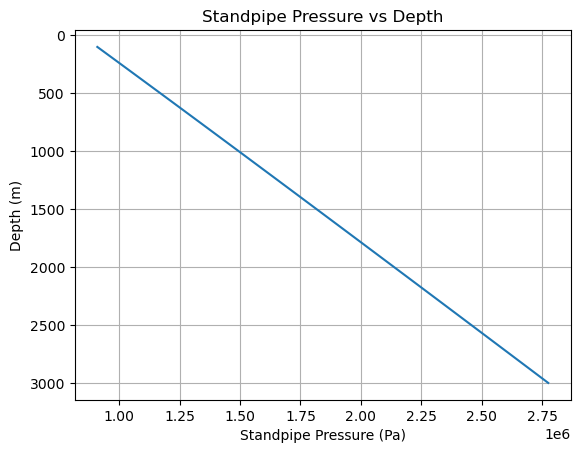

In [14]:
plt.figure()

plt.plot(spp_profile, depth_profile)

plt.gca().invert_yaxis()

plt.xlabel("Standpipe Pressure (Pa)")
plt.ylabel("Depth (m)")
plt.title("Standpipe Pressure vs Depth")

plt.grid(True)

plt.show()

Plot Component Breakdown

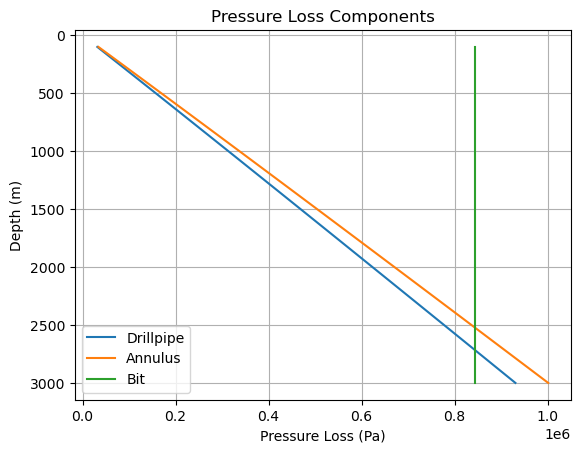

In [15]:
plt.figure()

plt.plot(dp_pipe_profile, depth_profile, label="Drillpipe")
plt.plot(dp_annulus_profile, depth_profile, label="Annulus")
plt.plot(dp_bit_profile, depth_profile, label="Bit")

plt.gca().invert_yaxis()

plt.xlabel("Pressure Loss (Pa)")
plt.ylabel("Depth (m)")
plt.title("Pressure Loss Components")

plt.legend()
plt.grid(True)

plt.show()

Save Results

In [16]:
results = pd.DataFrame({
    "Depth": depth_profile,
    "SPP": spp_profile,
    "DP_Pipe": dp_pipe_profile,
    "DP_Annulus": dp_annulus_profile,
    "DP_Bit": dp_bit_profile
})

results.to_csv("../results/spp_depth_profile.csv", index=False)

<IPython.core.display.Javascript object>